In [2]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_validation.gpkg'
mrt_name = 'MRT_1m-15dif.tif' 

# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)
mrt_path = os.path.join(base_dir, 'MRT-prediction', mrt_name)

#### reading and calibrating ground data 

In [4]:
gdf = gpd.read_file(ground_data_path)

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column start, 2026-02-17T13:38:25.282-03:00, successfully parsed
  return ogr_read(


In [18]:
gdf

,start,end,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,...,picture 1,picture 1_URL,picture 2,picture 2_URL,context,geometry,tg_corr,WIND M/S corr,wind_mean,MRT
0,2026-02-17 13:18:53.548000-03:00,2026-02-17 13:41:19.664000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,29.3,32.6,0.0,-31.370702,...,image-13_40_38.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_47.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24836 -31.36995),30.5124,0.010000,0.01,30.774178
1,2026-02-17 13:38:25.282000-03:00,2026-02-17 13:40:22.997000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.7,31.6,2.7,-31.370683,...,image-13_40_8.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24834 -31.36998),31.6000,1.923506,1.10,41.514903
2,2026-02-17 13:40:23.037000-03:00,2026-02-17 13:44:25.264000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,...,image-13_44_10.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_44_18.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24881 -31.37069),38.7000,0.671372,0.83,60.610154
3,2026-02-17 13:41:19.707000-03:00,2026-02-17 13:45:54.242000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,28.9,42.2,0.7,-31.370663,...,image-13_44_34.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_44_45.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24884 -31.37066),36.6468,0.700000,0.70,55.111709
4,2026-02-17 13:44:25.303000-03:00,2026-02-17 13:58:05.656000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,30.7,34.4,0.9,-31.361940,...,image-13_57_51.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_58_2.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,POINT (-64.23602 -31.36199),34.4000,0.010000,0.40,41.212535
5,2026-02-17 13:45:54.280000-03:00,2026-02-17 13:55:34.771000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,34.4,38.0,0.2,-31.366038,...,image-13_55_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_55_31.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (-64.24194 -31.36604),33.9630,0.200000,0.30,33.257695
6,2026-02-17 13:55:34.807000-03:00,2026-02-17 13:57:46.642000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,35.0,40.9,0.8,-31.366234,...,image-13_57_29.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_57_43.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (-64.24211 -31.36623),35.8161,0.800000,0.59,37.732581
7,2026-02-17 13:57:46.678000-03:00,2026-02-17 14:07:42.166000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,36.4,42.7,0.3,-31.366936,...,image-14_0_5.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-14_0_15.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (-64.2424 -31.36694),36.9663,0.300000,0.45,38.088486
8,2026-02-17 13:58:05.712000-03:00,2026-02-17 14:00:37.725000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.2,38.6,1.6,-31.361905,...,image-13_59_41.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_59_48.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,POINT (-64.23612 -31.3619),38.6000,0.671372,0.45,53.909283
9,2026-02-17 14:00:37.766000-03:00,2026-02-17 14:09:42.460000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.9,33.0,1.0,-31.366773,...,image-14_9_33.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-14_9_39.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.22041 -31.3665),33.0000,0.010000,0.33,39.817595


In [5]:
# calibrate TG1
# from notebook 3.4.4.1. 
gdf["tg_corr"] = np.where(
    gdf["Instrument"] == "T1 - Sper Scientific 800036 ",
    0.639 * gdf["TG"] + 9.681,   # apply correction for T1
    gdf["TG"]                    # keep original value for T2
)

In [6]:
# calibrate wind speed
# from notebook 3.4.4.2.
gdf["WIND M/S corr"] = np.where(gdf["Instrument"] == "T2 - TM-188D TENMARS ", (gdf["WIND M/S"] - 1.0102) / 0.8785, gdf["WIND M/S"])
gdf["WIND M/S corr"] = np.where(gdf["WIND M/S corr"] <= 0, 0.01, gdf["WIND M/S corr"]) # set minimum 0.01 to avoid issues


In [7]:
# compute mean of wind values
# because wind recorded is instantaneous, but TG is affected by wind conditions in the minutes before measurement

gdf["start"] = pd.to_datetime(gdf["start"], errors="coerce") # Convert to datetime
gdf = gdf.sort_values("start") # Sort by time
gdf = gdf.set_index("start") # Set as index

gdf["wind_mean"] = (
    gdf["WIND M/S corr"]
    .rolling(window="10min", center=True, min_periods=1) # Compute centered rolling mean over 10 minutes (±5 min)
    .mean()
    .round(2)
)

gdf = gdf.reset_index()

#### computing observed MRT and extracting predicted MRT values for ground data

In [ ]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(gdf["Instrument"] == "T1 - Sper Scientific 800036 ", D1,D2)

# MRT calculation using row-specific diameter
gdf["MRT"] = (
    (
        (gdf["tg_corr"] + 273.15)**4
        + (1.1e8 * gdf["wind_mean"]**0.6 / (eps * D2**0.4)) * (gdf["tg_corr"] - gdf["TA"]) # use D2 because TG values are calibrated to Thermometer 2
    )**0.25
    - 273.15
)

In [65]:
# read raster crs and sample values
with rasterio.open(mrt_path) as src:
    mrt_crs = src.crs
    points_proj = gdf.to_crs(mrt_crs)
    samples = list(src.sample(zip(points_proj.geometry.x, points_proj.geometry.y)))
    points_proj['MRT_predicted'] = [s[0] for s in samples]

points_proj['MRT_predicted'] = points_proj['MRT_predicted'].astype(float) 

# export gpkg
out_gpkg = os.path.join(base_dir, 'MRT-prediction/MRT_points_2026.gpkg')
points_proj.to_file(out_gpkg, driver="GPKG")


In [66]:
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']
points_proj['residuals'] = obs - pred

#### analysis

In [67]:
# Metrics

residuals = obs - pred

mae = np.mean(np.abs(residuals)).round(2)
rmse = np.sqrt(np.mean(residuals**2)).round(2)
bias = np.mean(residuals).round(2)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 5.44
RMSE: 6.43
Bias: 0.4


In [68]:
# plot

# Scatter
fig = px.scatter(
    points_proj,
    x=points_proj['MRT'],
    y=points_proj['MRT_predicted'],
    color=abs(points_proj['residuals']),
    hover_data=["tg_corr", "TA","wind_mean", "Instrument", "condition", "residuals", "WIND M/S", "context"],
)

# 1:1 line
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    line=dict(color="black", width=2), 
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="observed vs predicted MRT", 
    coloraxis_colorbar=dict(title="Residuals")
)


fig.show()


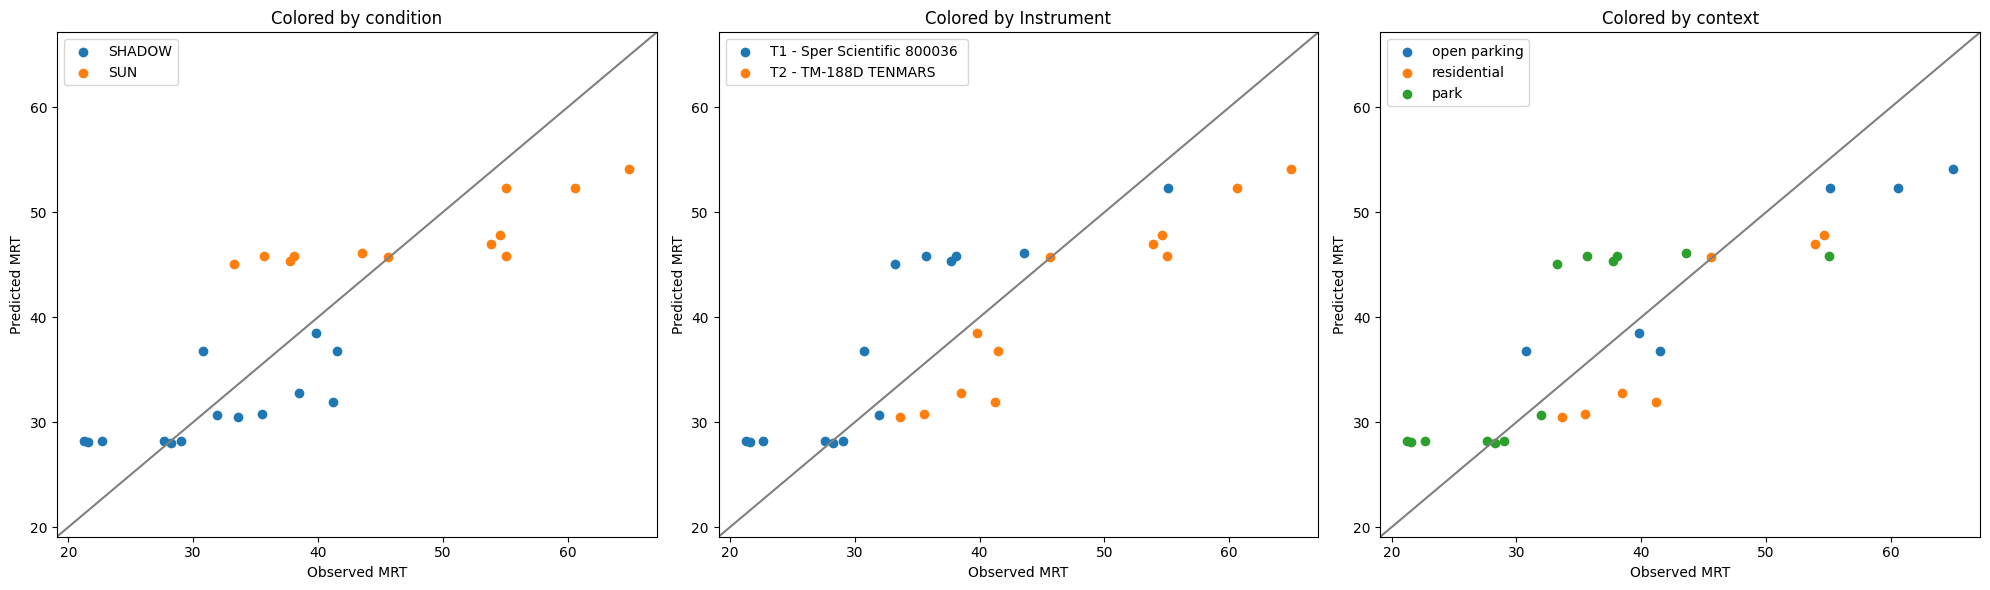

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Helper values
x = points_proj["MRT"]
y = points_proj["MRT_predicted"]

# 1) condition
for cond in points_proj["condition"].unique():
    mask = points_proj["condition"] == cond
    axes[0].scatter(x[mask], y[mask], label=cond)
axes[0].set_title("Colored by condition")
axes[0].set_xlabel("Observed MRT")
axes[0].set_ylabel("Predicted MRT")
axes[0].legend()


# 2) Instrument
for inst in points_proj["Instrument"].unique():
    mask = points_proj["Instrument"] == inst
    axes[1].scatter(x[mask], y[mask], label=inst)
axes[1].set_title("Colored by Instrument")
axes[1].set_xlabel("Observed MRT")
axes[1].set_ylabel("Predicted MRT")
axes[1].legend()


# 3) context
for ctx in points_proj["context"].unique():
    mask = points_proj["context"] == ctx
    axes[2].scatter(x[mask], y[mask], label=ctx)
axes[2].set_title("Colored by context")
axes[2].set_xlabel("Observed MRT")
axes[2].set_ylabel("Predicted MRT")
axes[2].legend()


# 1:1 reference line
for ax in axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

In [70]:
# Scatter
fig = px.scatter(
    points_proj,
    x=pred,
    y=residuals,
    color="context",
    hover_data=["TG", "TA","WIND M/S corr", "condition", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[pred.min(), pred.max()],
    y=[0, 0],
    mode="lines",
    name="Zero residual line"
)

fig.update_layout(
    xaxis_title="Predicted MRT °C",
    yaxis_title="Residuals (Obs - Pred)",
    title="points_proj residuals"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [71]:
metrics_residual = (
    points_proj
    .groupby("context")["residuals"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        count="count",
        mae=lambda x: np.mean(np.abs(x)),
        rmse=lambda x: np.sqrt(np.mean(x**2))
    )
)

metrics_residual

,mean,std,min,max,count,mae,rmse
context,,,,,,,
open parking,3.658085,5.911292,-6.013462,10.880905,6,5.662572,6.519284
park,-3.683678,5.766411,-11.842098,9.201357,13,5.450170,6.653057
residential,5.199980,3.039184,-0.162101,9.270778,7,5.246294,5.912437


<Figure size 800x600 with 0 Axes>

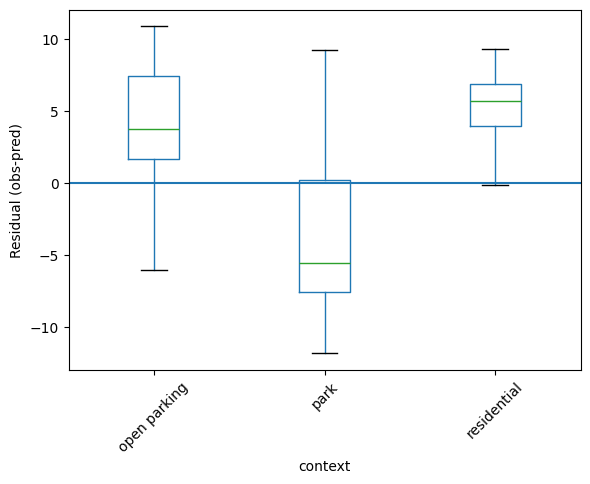

In [72]:
plt.figure(figsize=(8,6))

points_proj.boxplot(
    column="residuals",
    by="context",
    grid=False
)

plt.axhline(0)
plt.ylabel("Residual (obs-pred)")
plt.title("")
plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

From this we can understand the model limitations: It does not account for reflection from nearby objects nor for the different materials.
- in residential areas, where the roadway and nearby houses reflect radiation, the observed values were higher than the predicted ones.
- in open parkings, only the roadway reflects radiation, so the observed values were higher than the predicted ones but lower than in residential areas.
- in parks, where there are no nearby reflective objects, the observed values were lower than the predicted ones.